# Experiment No: 10
**Aim:** To implement a Convolutional Neural Network (2D CNN) using TensorFlow and Keras to classify images from the MNIST dataset.

--- Step 1: Load Data ---
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


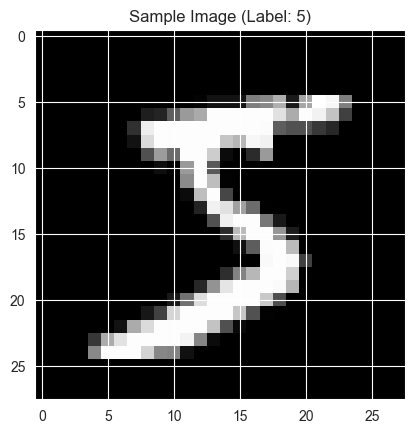

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import mnist

print("--- Step 1: Load Data ---")
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

plt.imshow(X_train[0], cmap='gray')
plt.title(f"Sample Image (Label: {y_train[0]})")
plt.show()

In [2]:
print("--- Step 2: Reshape and Normalize Data ---")
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)

print("New Training Shape:", X_train.shape)

# Normalize pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

--- Step 2: Reshape and Normalize Data ---
New Training Shape: (60000, 28, 28, 1)


In [3]:
print("--- Step 3 & 4: CNN Architecture & Compilation ---")
model = Sequential()

# Convolution Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Convolution Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
# Pooling Layer
model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))
# Dropout
model.add(Dropout(0.5))

# Output Layer (10 nodes for 0-9 digits)
model.add(Dense(10, activation='softmax'))

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

--- Step 3 & 4: CNN Architecture & Compilation ---


C:\Users\Divyanshu\Desktop\ML Lab\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
print("--- Step 5: Model Training ---")
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

--- Step 5: Model Training ---
Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 12s 13ms/step - accuracy: 0.9118 - loss: 0.2852 - val_accuracy: 0.9803 - val_loss: 0.0657
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9717 - loss: 0.0960 - val_accuracy: 0.9862 - val_loss: 0.0472
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9793 - loss: 0.0702 - val_accuracy: 0.9885 - val_loss: 0.0391
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9825 - loss: 0.0576 - val_accuracy: 0.9890 - val_loss: 0.0383
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9855 - loss: 0.0463 - val_accuracy: 0.9906 - val_loss: 0.0379



--- Step 6: Evaluation & Visualization ---
Test Accuracy: 99.11%
Test Loss: 0.0290

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Confusion Matrix:
[[ 975    0    0    0    0    0    3    1    1    0]
 [   0 1133    2    0    0    0    0    0    0    0]
 [   1    0 1026    1    0    0    0    4    0    0]
 [   0    0    2 1004    0    2    0    1    1    0]
 [   0    0    0    0  967    0    3    1    1   10]
 [   1    0    1    5    0  879    3    1    1    1]
 [   1    2    0    0    1    2  952    0    0    0]
 [   0    1    6    1    0    0    0 1018    1    1]
 [   1    0    2    1    0    0    0    1  965    4]
 [   2    3    0    1    2    2    1    5    1  992]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       1.00      0

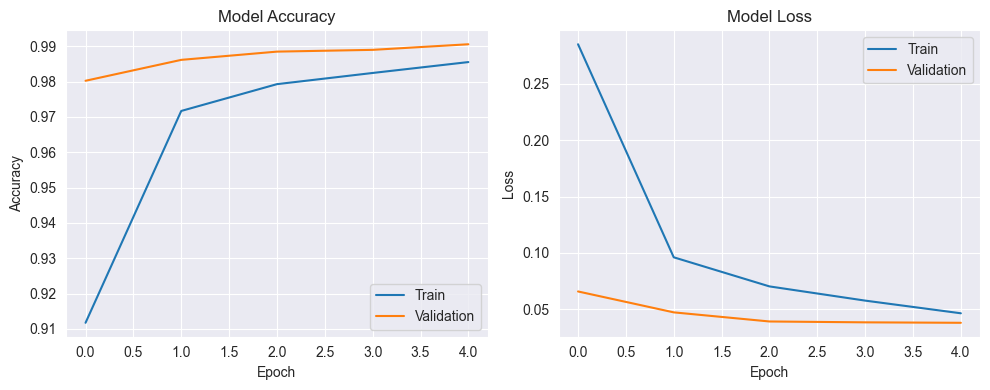

In [5]:
print("\n--- Step 6: Evaluation & Visualization ---")
from sklearn.metrics import confusion_matrix, classification_report

test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}\n")

predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(y_test, predicted_labels))

print("\nClassification Report:")
print(classification_report(y_test, predicted_labels))

# Plot Accuracy
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()